# DELTA Task 1: Neural Network Regression

Dependencies: this notebook uses `tensorflow`, `optuna`, `scikit-learn`, `pandas`, `numpy`, and `matplotlib`. If a package is missing, install it with `pip install tensorflow optuna scikit-learn pandas numpy matplotlib`.

This notebook follows the task requirements: data preprocessing, a linear benchmark, a tree-based benchmark, an untuned neural network benchmark, hyperparameter tuning for a regularized Keras/TensorFlow neural network, a train-vs-validation loss plot, a validation result table, and test-set prediction export.

## 1. Imports and Reproducibility

In [1]:
import os
import random
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
layers = keras.layers
regularizers = keras.regularizers
import optuna

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

## 2. Load and Inspect Data

In [2]:
train_X = pd.read_csv("DELTASS26_train_X.csv", index_col=0)
train_y = pd.read_csv("DELTASS26_train_y.csv", index_col=0)
test_X = pd.read_csv("DELTASS26_test_X.csv", index_col=0)
demo_predictions = pd.read_csv("Demo_Predictions.csv", index_col=0)

y = train_y.iloc[:, 0].astype(float)
print("train_X:", train_X.shape)
print("train_y:", train_y.shape)
print("test_X:", test_X.shape)
print("Missing values:", int(train_X.isna().sum().sum() + train_y.isna().sum().sum() + test_X.isna().sum().sum()))
train_X.describe().T.head(10)

train_X: (1875, 19)
train_y: (1875, 1)
test_X: (625, 19)
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
0,1875.0,130.163520,809.854500,-1674.071687,-548.874484,183.575833,689.650401,1860.785558
1,1875.0,171.013546,40.782851,87.546567,132.798064,171.579235,207.438889,269.044614
2,1875.0,63.788460,58.237394,-57.119117,7.865111,98.352066,114.239671,130.817338
3,1875.0,-670.549888,7982.156868,-25702.969887,-6509.396092,-684.980103,4906.378128,35921.510413
5,1875.0,78.245281,84.385152,-100.675317,8.815478,104.977293,148.637297,199.393752
6,1875.0,117.458967,709.962766,-2162.212017,-276.696548,118.973174,550.703198,2177.422910
7,1875.0,1150.512149,805.450255,-1557.247601,620.178161,1009.029903,1544.898766,5776.535629
8,1875.0,112.115513,4.506136,102.967668,109.398591,111.328289,113.719073,150.893491
9,1875.0,259.753742,281.696634,-177.677089,-8.665133,296.361254,548.945756,738.050011
10,1875.0,-13.509580,124.804064,-323.113446,-125.094572,7.666119,108.463600,182.093603


The predictor variables have very different scales, so the linear model and neural networks use standardized inputs. The neural-network target is also standardized during training and transformed back to the original scale for RMSE evaluation and submission.

## 3. Train/Validation Split and Preprocessing

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    train_X, y, test_size=0.2, random_state=RANDOM_STATE
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
test_X_scaled = x_scaler.transform(test_X)

y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

results = []

## 4. Benchmark Models

In [4]:
# Linear benchmark
linear_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scale", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 6, 80))),
    ]),
    transformer=StandardScaler(),
)
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_val)
results.append({"Model": "Ridge regression", "Validation RMSE": rmse(y_val, linear_pred)})

# Tree-based benchmark
tree_model = RandomForestRegressor(
    n_estimators=600,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_val)
results.append({"Model": "Random forest", "Validation RMSE": rmse(y_val, tree_pred)})

pd.DataFrame(results)

,Model,Validation RMSE
0,Ridge regression,86.858516
1,Random forest,49.272728


In [5]:
def build_baseline_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

tf.keras.backend.clear_session()
baseline_nn = build_baseline_nn(X_train_scaled.shape[1])
baseline_history = baseline_nn.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=150,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0,
)

baseline_pred_scaled = baseline_nn.predict(X_val_scaled, verbose=0).ravel()
baseline_pred = y_scaler.inverse_transform(baseline_pred_scaled.reshape(-1, 1)).ravel()
results.append({"Model": "Untuned neural network", "Validation RMSE": rmse(y_val, baseline_pred)})
pd.DataFrame(results).sort_values("Validation RMSE")

,Model,Validation RMSE
2,Untuned neural network,34.694261
1,Random forest,49.272728
0,Ridge regression,86.858516


## 5. Hyperparameter Tuning for the Neural Network

In [6]:
def build_tuned_nn(params, input_dim):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for i in range(params["n_layers"]):
        model.add(layers.Dense(
            params[f"units_l{i}"],
            activation=params["activation"],
            kernel_regularizer=regularizers.l2(params["l2"]),
        ))
        if params["batch_norm"]:
            model.add(layers.BatchNormalization())
        if params["dropout"] > 0:
            model.add(layers.Dropout(params["dropout"]))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(params["lr"]), loss="mse")
    return model

def objective(trial):
    tf.keras.backend.clear_session()
    params = {
        "n_layers": trial.suggest_int("n_layers", 1, 4),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.30),
        "l2": trial.suggest_float("l2", 1e-7, 1e-2, log=True),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "batch_norm": trial.suggest_categorical("batch_norm", [True, False]),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
    }
    for i in range(params["n_layers"]):
        params[f"units_l{i}"] = trial.suggest_categorical(f"units_l{i}", [32, 64, 128, 256])
    model = build_tuned_nn(params, X_train_scaled.shape[1])
    model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=160,
        batch_size=params["batch_size"],
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=16, restore_best_weights=True)],
        verbose=0,
    )
    pred_scaled = model.predict(X_val_scaled, verbose=0).ravel()
    pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    return rmse(y_val, pred)

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=24, show_progress_bar=False)
best_params = study.best_params
print("Best validation RMSE:", study.best_value)
best_params

Best validation RMSE: 23.410802280428996


{'n_layers': 2,
 'activation': 'tanh',
 'dropout': 0.03629425181743662,
 'l2': 2.056668743885319e-07,
 'lr': 0.0007684043912121237,
 'batch_norm': False,
 'batch_size': 16,
 'units_l0': 256,
 'units_l1': 256}

## 6. Train Best Neural Network and Plot Loss

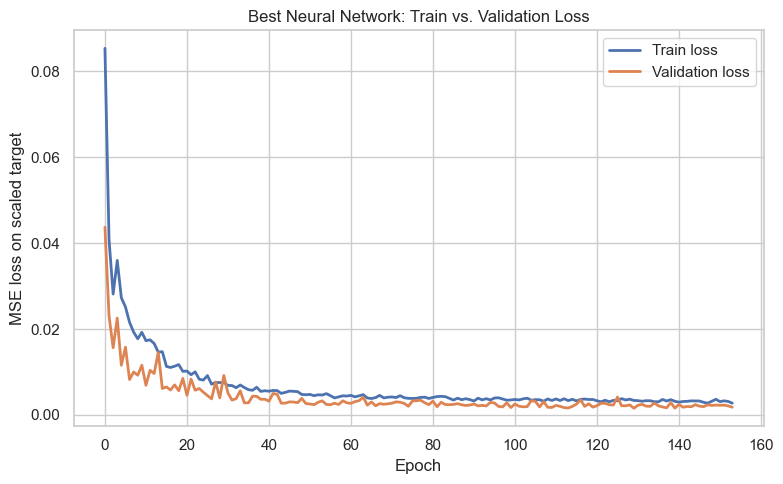

Best tuned NN validation RMSE: 22.917959716019553


In [7]:
tf.keras.backend.clear_session()
best_nn = build_tuned_nn(best_params, X_train_scaled.shape[1])
best_history = best_nn.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=240,
    batch_size=best_params["batch_size"],
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=24, restore_best_weights=True)],
    verbose=0,
)

best_pred_scaled = best_nn.predict(X_val_scaled, verbose=0).ravel()
best_pred = y_scaler.inverse_transform(best_pred_scaled.reshape(-1, 1)).ravel()
results.append({"Model": "Tuned neural network", "Validation RMSE": rmse(y_val, best_pred)})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(best_history.history["loss"], label="Train loss", linewidth=2)
ax.plot(best_history.history["val_loss"], label="Validation loss", linewidth=2)
ax.set_title("Best Neural Network: Train vs. Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss on scaled target")
ax.legend()
fig.tight_layout()
fig.savefig("best_nn_train_validation_loss.png", dpi=160)
plt.show()

print("Best tuned NN validation RMSE:", rmse(y_val, best_pred))

## 7. Validation Result Table

In [8]:
results_table = pd.DataFrame(results).sort_values("Validation RMSE").reset_index(drop=True)
results_table.to_csv("validation_results.csv", index=False)
results_table

,Model,Validation RMSE
0,Tuned neural network,22.917960
1,Untuned neural network,34.694261
2,Random forest,49.272728
3,Ridge regression,86.858516


## 8. Architecture Interpretation

The best neural network is suitable because standardized inputs allow the dense layers to learn nonlinear feature interactions without being dominated by large-scale predictors. L2 regularization, dropout, batch normalization when selected, and early stopping reduce overfitting on a relatively small training set. I select the tuned neural network because it is the required optimized Keras/TensorFlow model and its validation loss curve is used to check generalization.

## 9. Final Test Predictions from the Tuned Neural Network

In [9]:
final_x_scaler = StandardScaler()
final_y_scaler = StandardScaler()
X_full_scaled = final_x_scaler.fit_transform(train_X)
test_full_scaled = final_x_scaler.transform(test_X)
y_full_scaled = final_y_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()

tf.keras.backend.clear_session()
final_nn = build_tuned_nn(best_params, X_full_scaled.shape[1])
final_nn.fit(
    X_full_scaled,
    y_full_scaled,
    validation_split=0.15,
    epochs=280,
    batch_size=best_params["batch_size"],
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=28, restore_best_weights=True)],
    verbose=0,
)

test_pred_scaled = final_nn.predict(test_full_scaled, verbose=0).ravel()
test_pred = final_y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel()
submission = pd.DataFrame({"Predictions": test_pred}, index=demo_predictions.index)
submission.to_csv("DELTA_Task1_Predictions.csv")
print(submission.shape)
submission.head()

(625, 1)


,Predictions
0,-884.661682
1,880.012390
2,559.687683
3,927.802856
4,-301.156189
